In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import wandb

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [3]:
import kagglehub

path = kagglehub.dataset_download("jtiptj/chest-xray-pneumoniacovid19tuberculosis")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumoniacovid19tuberculosis' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumoniacovid19tuberculosis


In [4]:
print("Path:", path)
print(os.listdir(path))

Path: /kaggle/input/chest-xray-pneumoniacovid19tuberculosis
['val', 'test', 'train']


In [5]:
train_dir = os.path.join(path, 'train')
val_dir = os.path.join(path, 'val')
test_dir = os.path.join(path, 'test')


In [6]:
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [7]:
print(os.listdir(test_dir))

['PNEUMONIA', 'NORMAL', 'COVID19', 'TURBERCULOSIS']


In [8]:
for cls in ["PNEUMONIA", "NORMAL"]:
  folder_path = os.path.join(train_dir, cls)
  print(cls, len(os.listdir(folder_path)))

PNEUMONIA 3875
NORMAL 1341


In [9]:
pneumonia_dir = os.path.join(train_dir, "PNEUMONIA")
normal_dir = os.path.join(train_dir, "NORMAL")

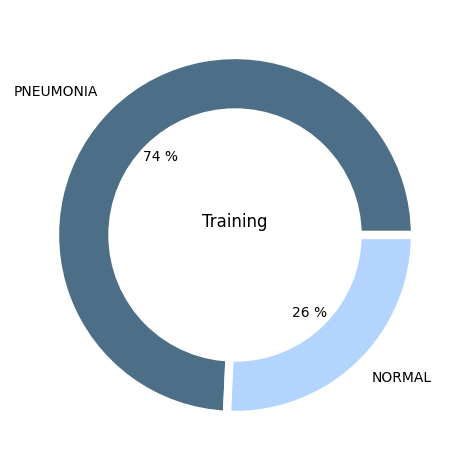

In [10]:
plt.pie([len(os.listdir(pneumonia_dir)), len(os.listdir(normal_dir))], labels=['PNEUMONIA', 'NORMAL'], colors= ['#4c6f87', '#b3d4ff','#8fb3d9', '#e1f0ff'], autopct='%.0f %%', wedgeprops={'linewidth': 6, 'edgecolor': 'white'})
my_circle = plt.Circle((0, 0), 0.70, color='white')
p = plt.gcf()
p.gca().add_artist(my_circle)
plt.axis('off')
plt.title('Training', x=0.5, y=0.5)
plt.tight_layout()

In [11]:
files = os.listdir(pneumonia_dir)

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

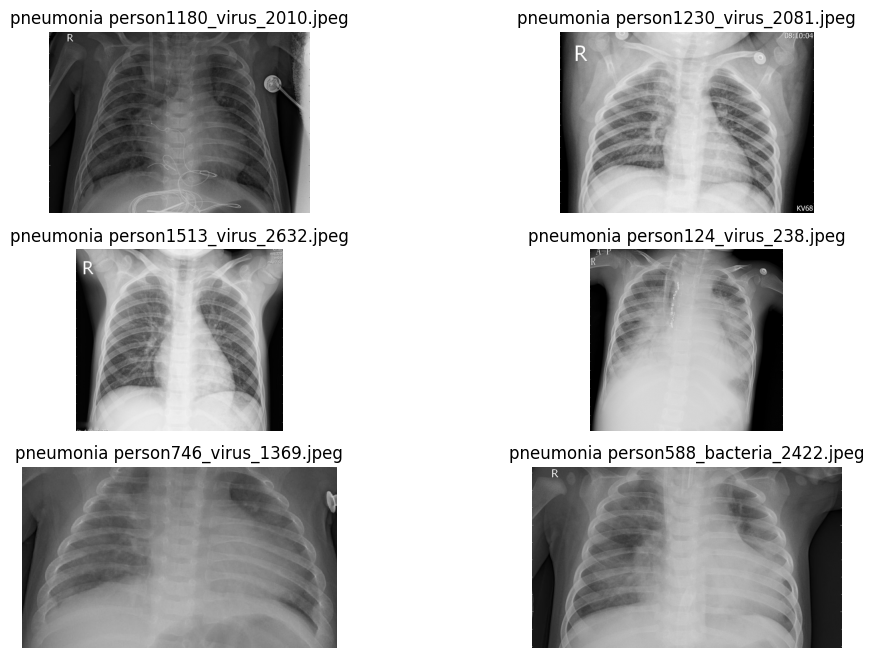

In [12]:
plt.figure(figsize=(12, 8))
for i in range(6):
  img_path = os.path.join(pneumonia_dir, files[i])
  img = Image.open(img_path)

  plt.subplot(3, 2, i + 1)
  plt.imshow(img, cmap='gray')
  plt.title(f"pneumonia {files[i]}")
  plt.axis('off')

plt

In [13]:
target_classes = ["NORMAL", "PNEUMONIA"]

print(os.listdir(train_dir))

['PNEUMONIA', 'NORMAL', 'COVID19', 'TURBERCULOSIS']


In [14]:
def make_image_df(base_dir, split_name):
    rows = []
    for label in target_classes:
        folder = os.path.join(base_dir, label)

        for file_name in os.listdir(folder):
            file_path = os.path.join(folder, file_name)

            rows.append({
                "path": file_path,
                "label": label,
                "split": split_name
            })

    return pd.DataFrame(rows)

In [15]:
train_df = make_image_df(train_dir, "train")
val_df = make_image_df(val_dir, "val")
test_df = make_image_df(test_dir, "test")

df = pd.concat([train_df, val_df, test_df], ignore_index=True)

df.head()

,path,label,split
0,/kaggle/input/chest-xray-pneumoniacovid19tuber...,NORMAL,train
1,/kaggle/input/chest-xray-pneumoniacovid19tuber...,NORMAL,train
2,/kaggle/input/chest-xray-pneumoniacovid19tuber...,NORMAL,train
3,/kaggle/input/chest-xray-pneumoniacovid19tuber...,NORMAL,train
4,/kaggle/input/chest-xray-pneumoniacovid19tuber...,NORMAL,train


In [16]:
df.groupby(["split", "label"]).size()

split  label    
test   NORMAL        234
       PNEUMONIA     390
train  NORMAL       1341
       PNEUMONIA    3875
val    NORMAL          8
       PNEUMONIA       8
dtype: int64

In [17]:
label_to_id = {
    "NORMAL": 0,
    "PNEUMONIA": 1
}

id_to_label = {
    0: "NORMAL",
    1: "PNEUMONIA"
}

In [18]:
class XRayDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        image = Image.open(row["path"]).convert("RGB")
        label = label_to_id[row["label"]]

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

In [19]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [20]:
batch_size = 32

train_dataset = XRayDataset(train_df, transform=train_transform)
val_dataset = XRayDataset(val_df, transform=eval_transform)
test_dataset = XRayDataset(test_df, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

In [21]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 1)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.shared_mlp = nn.Sequential(
            nn.Conv2d(channels, hidden, kernel_size=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, kernel_size=1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_attention = self.shared_mlp(self.avg_pool(x))
        max_attention = self.shared_mlp(self.max_pool(x))

        attention = self.sigmoid(avg_attention + max_attention)

        return attention

In [22]:
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()

        padding = kernel_size // 2
        self.conv = nn.Conv2d(
            in_channels=2,
            out_channels=1,
            kernel_size=kernel_size,
            padding=padding,
            bias=False
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_map = torch.mean(x, dim=1, keepdim=True)
        max_map, _ = torch.max(x, dim=1, keepdim=True)

        attention_input = torch.cat([avg_map, max_map], dim=1)
        attention = self.sigmoid(self.conv(attention_input))

        return attention

In [23]:
class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()

        self.channel_attention = ChannelAttention(channels, reduction)
        self.spatial_attention = SpatialAttention(kernel_size)

    def forward(self, x):
        x = x * self.channel_attention(x)
        x = x * self.spatial_attention(x)

        return x

In [24]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, use_cbam=True):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels,out_channels,kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        ]

        if use_cbam:
            layers.append(CBAMBlock(out_channels))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

In [25]:
class PneumoniaCBAMCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            CBAM(32),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            CBAM(64),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            CBAM(128),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            CBAM(256),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            CBAM(512),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)

        return x

In [26]:
model = PneumoniaCBAMCNN(num_classes=2).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print(model)

Total parameters: 1,745,548
PneumoniaCBAMCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): CBAM(
      (channel_attention): ChannelAttention(
        (avg_pool): AdaptiveAvgPool2d(output_size=1)
        (max_pool): AdaptiveMaxPool2d(output_size=1)
        (shared_mlp): Sequential(
          (0): Conv2d(32, 2, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): ReLU(inplace=True)
          (2): Conv2d(2, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        )
        (sigmoid): Sigmoid()
      )
      (spatial_attention): SpatialAttention(
        (conv): Conv2d(2, 1, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), bias=False)
        (sigmoid): Sigmoid()
      )
    )
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kern

In [27]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

In [28]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0
    all_preds = []
    all_targets = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)

    return avg_loss, acc

In [29]:
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    all_preds = []
    all_targets = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = outputs.argmax(dim=1)

            total_loss += loss.item() * images.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)

    acc = accuracy_score(all_targets, all_preds)
    precision = precision_score(all_targets, all_preds, pos_label=1, zero_division=0)
    recall = recall_score(all_targets, all_preds, pos_label=1, zero_division=0)
    f1 = f1_score(all_targets, all_preds, pos_label=1, zero_division=0)

    return avg_loss, acc, precision, recall, f1

In [30]:

os.environ["WANDB_API_KEY"] = "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"
wandb.init(
    project="gp5-project",
    name="cnn_cbam",
    config={
        "model": "PneumoniaCBAMCNN",
        "epochs": 25,
        "batch_size": batch_size,
        "lr": 1e-4,
        "seed": SEED,
    },
    reinit=True,
)
wandb.watch(model, log_freq=100)

num_epochs = 25

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": []
}

best_val_f1 = 0
best_model_path = "cnn_cbam_pneumonia.pt"

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc, val_precision, val_recall, val_f1 = evaluate(
        model, val_loader, criterion, device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_precision"].append(val_precision)
    history["val_recall"].append(val_recall)
    history["val_f1"].append(val_f1)

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"train_loss: {train_loss:.4f} | "
        f"train_acc: {train_acc:.4f} ||| "
        f"val_loss: {val_loss:.4f} | "
        f"val_acc: {val_acc:.4f} | "
        f"val_recall: {val_recall:.4f} | "
        f"val_f1: {val_f1:.4f}"
    )

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_precision": val_precision,
        "val_recall": val_recall,
        "val_f1": val_f1,
    })

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), best_model_path)

wandb.summary["best_val_f1"] = best_val_f1

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: snigirev576 (snigirev576-hse) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch 1/25 | train_loss: 0.3062 | train_acc: 0.8758 ||| val_loss: 1.5302 | val_acc: 0.5625 | val_recall: 1.0000 | val_f1: 0.6957
Epoch 2/25 | train_loss: 0.1659 | train_acc: 0.9379 ||| val_loss: 1.6177 | val_acc: 0.5625 | val_recall: 1.0000 | val_f1: 0.6957
Epoch 3/25 | train_loss: 0.1228 | train_acc: 0.9574 ||| val_loss: 0.8781 | val_acc: 0.6250 | val_recall: 1.0000 | val_f1: 0.7273
Epoch 4/25 | train_loss: 0.1106 | train_acc: 0.9618 ||| val_loss: 0.8751 | val_acc: 0.6875 | val_recall: 1.0000 | val_f1: 0.7619
Epoch 5/25 | train_loss: 0.0898 | train_acc: 0.9649 ||| val_loss: 2.1992 | val_acc: 0.5625 | val_recall: 1.0000 | val_f1: 0.6957
Epoch 6/25 | train_loss: 0.0873 | train_acc: 0.9674 ||| val_loss: 1.7438 | val_acc: 0.5625 | val_recall: 1.0000 | val_f1: 0.6957
Epoch 7/25 | train_loss: 0.0834 | train_acc: 0.9716 ||| val_loss: 0.6849 | val_acc: 0.6875 | val_recall: 1.0000 | val_f1: 0.7619
Epoch 8/25 | train_loss: 0.0808 | train_acc: 0.9703 ||| val_loss: 0.5161 | val_acc: 0.7500 | val_

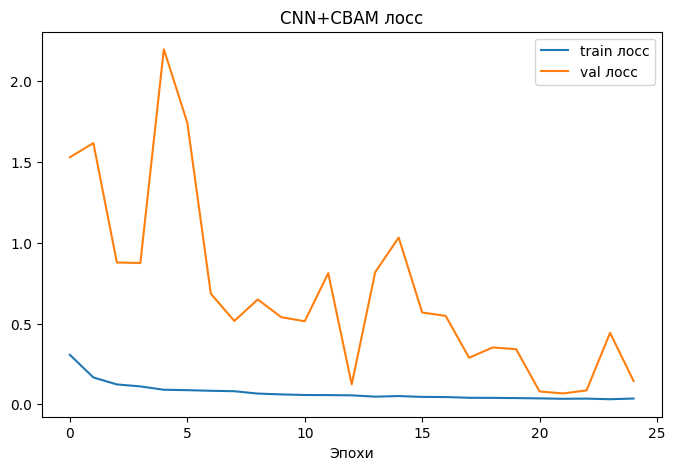

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="train лосс")
plt.plot(history["val_loss"], label="val лосс")
plt.title("CNN+CBAM лосс")
plt.xlabel("Эпохи")
plt.legend()
plt.show()

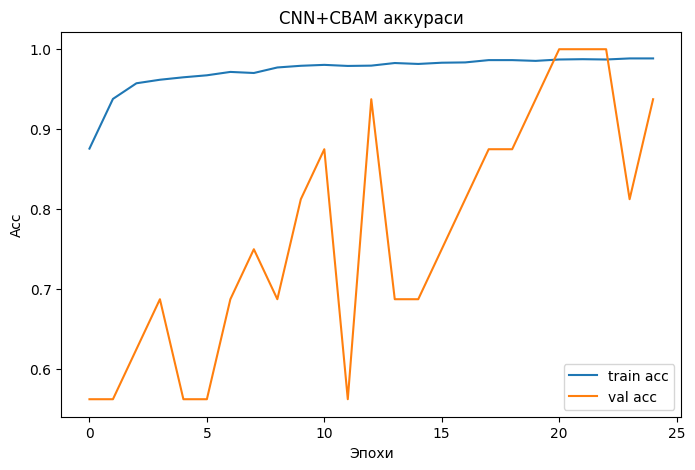

In [32]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="train acc")
plt.plot(history["val_acc"], label="val acc")
plt.title("CNN+CBAM аккураси")
plt.xlabel("Эпохи")
plt.ylabel("Acc")
plt.legend()
plt.show()

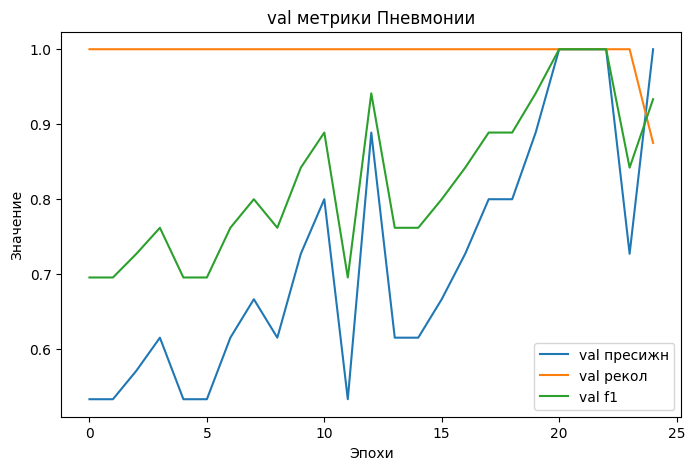

In [33]:
plt.figure(figsize=(8, 5))
plt.plot(history["val_precision"], label="val пресижн")
plt.plot(history["val_recall"], label="val рекол")
plt.plot(history["val_f1"], label="val f1")
plt.title("val метрики Пневмонии")
plt.xlabel("Эпохи")
plt.ylabel("Значение")
plt.legend()
plt.show()

In [34]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)

test_loss, test_acc, test_precision, test_recall, test_f1 = evaluate(
    model, test_loader, criterion, device
)
print("Test loss:", round(test_loss, 4))
print("\nTest accuracy:", round(test_acc, 4))
print("Test precision:", round(test_precision, 4))
print("Test recall:", round(test_recall, 4))
print("Test f1:", round(test_f1, 4))

wandb.log({
    "test_loss": test_loss,
    "test_acc": test_acc,
    "test_precision": test_precision,
    "test_recall": test_recall,
    "test_f1": test_f1,
})

artifact = wandb.Artifact("cnn_cbam_model", type="model")
artifact.add_file(best_model_path)
wandb.log_artifact(artifact)
wandb.finish()

Test loss: 0.758
Test accuracy: 0.8189
Test precision: 0.7821
Test recall: 0.9846
Test f1: 0.8717


epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
test_acc,▁
test_f1,▁
test_loss,▁
test_precision,▁
test_recall,▁
train_acc,▁▅▆▆▇▇▇▇▇▇▇▇▇████████████
train_loss,█▄▃▃▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁
val_acc,▁▁▂▃▁▁▃▄▃▅▆▁▇▃▃▄▅▆▆▇███▅▇
val_f1,▁▁▂▃▁▁▃▃▃▄▅▁▇▃▃▃▄▅▅▇███▄▆
+3,...
